In [1]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
import sys

import os
import glob
import json
import matplotlib.pyplot as plt
import numpy as np

# Function to find the project root directory
for parent in [Path.cwd().resolve()] + list(Path.cwd().resolve().parents):
    if (parent / "utils").exists():
        sys.path.insert(0, str(parent))
        break

from utils.pathing import setup_repo_path
ROOT = setup_repo_path()
print(f"Project root set to: {ROOT}")
# -----------------------------------------------

from main import main
from limit_states import REGISTRY as ls_REGISTRY

Project root set to: D:\active_train\acquisition\MOO-AL


Define config file

In [2]:
config = {}
# Config file for the active learning experiment
config = {
    'case_study':'four_branch_7', # 'four_branch_6', 'four_branch_7', 'hat', 'himmelblau', 'nonlinear_oscillator', 'high_dimensional'
    'al_strategy': 'u', # 'u', 'eff', 'moo', 'erf', 'reif'
    'al_batch': 1, # Number of samples to acquired at each AL iteration
    'total_samples': 100, # Total number of training samples
    'passive_samples': 10, # Initial dataset size (LHS)
    'n_mcs_pool': 1000000, # Number of samples in the MCS pool
    'n_mcs_pf': 10000000, # Number of samples for the MCS probability of failure estimate
    'seed': None,  # Random seed for reproducibility (264407567 to test high dimensional case study)
    'save_interval': 100, # Save the model every n iterations
    'pareto_metrics': False, # If True, save the Pareto front at every AL iteration
    'wand_online': False
}

Config parameters for MOO-based acquisition strategies

In [3]:
# Define the acquisition strategy for MOO-based training
if config['al_strategy'] == 'moo':
    # Multi-objective optimization methods
    config['moo_method'] = 'reliability' # 'knee', 'compromise', 'reliability'

    # Add relevant parameters for the MOO-R method
    if config['moo_method'] == 'reliability':
        config['N_it'] = 2 # Number of iterations for active learning
        config['delta_p0'] = 0.2 # threshold of relative difference in reliabity estimate at which gamma=0.5
        config['k_balance'] = 40 # Positive constant controlling how quickly gamma transition from 0 to 1

    # epsilon-greedy schedule state
    if config['moo_method'] == "eps_greedy" or config['moo_method'] == "eps_lw":
        config['eps_start'] = 1
        config['eps_end']   = 0
        config['eps_T']     = 100
        config['_eps_t']    = 0  # internal call counter

if config['al_strategy'] == 'portfolio':
    # Portfolio strategy parameters
    config['portfolio_lambda'] = 2.0  # Hedge balance (λ)
    config['portfolio_delta'] = 0.7    # Memory factor (δ)

Run active learning loop

In [4]:
name_exp = 'u_test'
main(config=config, name_exp=name_exp)

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.


Experiment settings: {'case_study': 'four_branch_7', 'al_strategy': 'u', 'al_batch': 1, 'total_samples': 100, 'passive_samples': 10, 'n_mcs_pool': 1000000, 'n_mcs_pf': 10000000, 'seed': 408286767, 'save_interval': 100, 'pareto_metrics': False, 'wand_online': False, 'name_exp': 'u_test'} 

Reference Pf: 2.265E-03 

Training samples: 10 | Pf_model: 0.000E+00, Pf_rel_diff: -1.00E+00, B_rel_diff: INF, LML = -1.10E+01
Training samples: 11 | Pf_model: 8.926E-04, Pf_rel_diff: -6.06E-01, B_rel_diff: 1.00E-01, LML = -8.59E+00
Training samples: 12 | Pf_model: 6.454E-04, Pf_rel_diff: -7.15E-01, B_rel_diff: 1.34E-01, LML = -7.86E+00
Training samples: 13 | Pf_model: 8.200E-04, Pf_rel_diff: -6.38E-01, B_rel_diff: 1.09E-01, LML = -6.55E+00
Training samples: 14 | Pf_model: 8.814E-04, Pf_rel_diff: -6.11E-01, B_rel_diff: 1.02E-01, LML = -5.68E+00
Training samples: 15 | Pf_model: 9.042E-04, Pf_rel_diff: -6.01E-01, B_rel_diff: 9.91E-02, LML = -4.99E+00
Training samples: 16 | Pf_model: 8.806E-04, Pf_rel_di

B_rel_diff,█▆▆▆▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▂▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁
LML,▁▁▁▁▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇██
Pf_model,▁▃▄▄▄████████████████▇███████████▇██████
Pf_rel_diff,▁▃▄▄▄████████████████▇███████████▇██████
train_size,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
B_rel_diff,0.0287
LML,401.2255
Pf_model,0.00175
Pf_rel_diff,-0.22768
train_size,101


Active learning completed in: 9.51 mins


Loading results

In [5]:
base = 'results'
name_exp_load = 'reif_test2' #name_exp if same as current experiment else specify the name

# Base results directory
script_folder = os.getcwd() # Current directory 
base_results_dir = os.path.join(
    script_folder,  
    base
)

# Construct the directory pattern based on the configuration
if config['al_strategy'] == 'moo':
    
    dir_pattern = os.path.join(
    base_results_dir, 
    config['case_study'], 
    f"{config['al_strategy']}_{config['moo_method']}_{config['al_batch']}_{name_exp_load}_*"
)
else:
    dir_pattern = os.path.join(
        base_results_dir, 
        config['case_study'], 
        f"{config['al_strategy']}_{config['al_batch']}_{name_exp_load}_*"
    )
# Find all directories matching the pattern
matching_dirs = glob.glob(dir_pattern)
output_json_path = os.path.join(matching_dirs[0], 'output.json')

# Load the output.json file if it exists
if os.path.isfile(output_json_path):
    with open(output_json_path, 'r') as f:
        output_data = json.load(f)

Plot Pf evolution

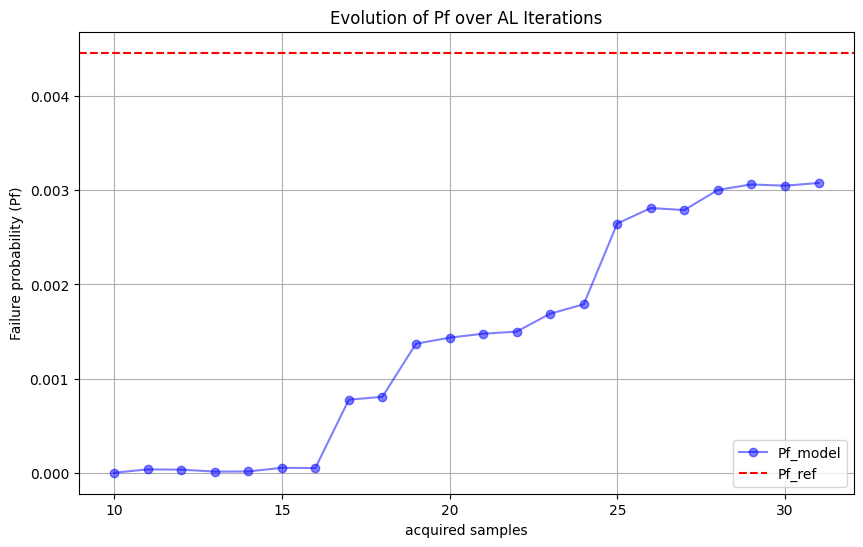

In [6]:
# Loading limit state and ref. Pf
lstate = ls_REGISTRY[config['case_study']]()
Pf_ref = lstate.target_pf

# Extract the Pf_model values
pf_model = output_data['Pf_model']

# Generate the x-axis values starting from config['passive_samples']
iterations = range(config['passive_samples'], config['passive_samples'] + len(pf_model))

# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(iterations, pf_model, marker='o', linestyle='-', color='b', label='Pf_model', alpha=0.5)
plt.axhline(y=Pf_ref, color='r', linestyle='--', label='Pf_ref')
plt.xlabel('acquired samples')
plt.ylabel('Failure probability (Pf)')
plt.title('Evolution of Pf over AL Iterations')
plt.legend()
# plt.ylim(0, 2.5e-3)
plt.grid(True)
plt.show()

In [7]:
import matplotlib.pyplot as plt
from collections import Counter

if config['al_strategy'] == 'portfolio':
    history = output_data['portfolio_history']

    counts = Counter(history)
    labels = list(counts.keys())
    values = list(counts.values())

    plt.figure(figsize=(6,4))
    plt.bar(labels, values)
    plt.title("Portfolio Participation")
    plt.ylabel("Selections")
    plt.xlabel("Acquisition Function")
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.show()


Plot Pareto samples per Al iteration

In [8]:
import numpy as np
import matplotlib.pyplot as plt

if config['al_strategy'] == 'portfolio':
    history = output_data['portfolio_history']
    pf_model = np.asarray(output_data['Pf_model'])

    start = config['passive_samples']
    iterations = np.arange(start, start + len(pf_model))

    # Map each learning function to a color + marker
    lf_styles = {
        "u":     ("red",     "o"),
        "eff":   ("green",   "s"),
        "erf":   ("blue",    "D"),
        "reif":  ("orange",  "^"),
        "reif2": ("purple",  "v"),
    }

    plt.figure(figsize=(12, 6))

    # Background Pf curve
    plt.plot(iterations, pf_model, color="black", linewidth=1.2, alpha=0.3, label="Pf_model")

    # --- automatic alignment between history and pf_model ---
    len_hist = len(history)
    len_pf   = len(pf_model)

    # offset = index in pf_model corresponding to history[0]
    offset = len_pf - len_hist
    # common cases:
    #  - offset == 0  -> history[k] ↔ pf_model[k]
    #  - offset == 1  -> history[k] ↔ pf_model[k+1]

    # Keep track of which labels we've already added to the legend
    used_labels = set()

    for i, lf in enumerate(history):
        idx = i + offset
        if not (0 <= idx < len_pf):
            # safety: skip any misaligned indices
            continue

        color, marker = lf_styles.get(lf, ("gray", "o"))
        label = lf if lf not in used_labels else ""
        used_labels.add(lf)

        plt.scatter(
            iterations[idx],
            pf_model[idx],
            color=color,
            marker=marker,
            s=70,
            label=label,
            zorder=3,
        )

    plt.xlabel("Iteration")
    plt.ylabel("Pf estimate")
    plt.title("Evolution of Pf with Portfolio Learning Function Participation")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

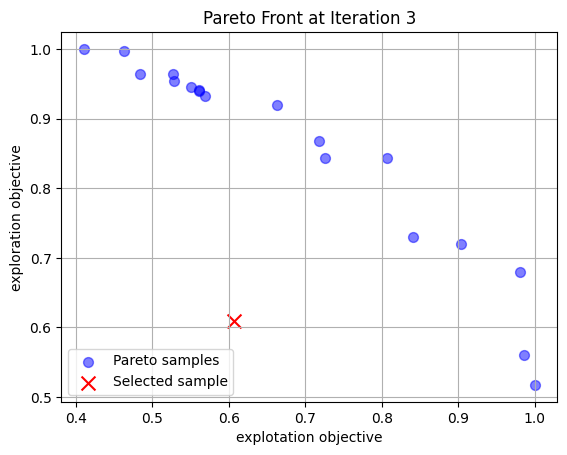

In [12]:
# iteration index for Pareto metrics
i = 3

# Extract the first element of output_data['Pareto_metrics'][i]
first_element = np.array(output_data['Pareto_metrics'][i][0])

# Extract X and Y for the first element
x1 = first_element[:, 0]  # First column
y1 = first_element[:, 1]  # Second column

# Extract the second element of output_data['Pareto_metrics'][i]
second_element = np.array(output_data['Pareto_metrics'][i][1])

# Extract X and Y for the second element
x2 = second_element[0]  # First column
y2 = second_element[1]  # Second column

# Plot the first element
plt.scatter(x1+1, y1, label='Pareto samples', s=50, color='blue', alpha=0.5)

# Plot the second element
plt.scatter(1-x2, y2, label='Selected sample', color='red', marker='x', s=100)

# Add labels, legend, and title
plt.xlabel('explotation objective')
plt.ylabel('exploration objective')
plt.title(f'Pareto Front at Iteration {i}')
plt.grid(True)
plt.legend(loc='lower left')

# Show the plot
plt.show()

Loading training samples

In [ ]:
x_training = np.array(output_data['training_samples'][0], dtype=np.float64)
y_training = np.array(output_data['training_samples'][1], dtype=np.float64)

In [ ]:
import torch
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel

from utils.data import isoprobabilistic_transform, custom_optimizer, normalize_tensor, parallel_predict

seed_exp = config['seed']

# experiment seed for reproducibility
if seed_exp is None:
    seed_exp = np.random.randint(0, 2**30 - 1)
else:
    seed_exp=int(seed_exp)

print(f"Using experiment seed: {seed_exp}")
np.random.seed(seed_exp)
torch.manual_seed(seed_exp)
random_state = np.random.RandomState(seed_exp)

lstate = ls_REGISTRY[config['case_study']]()

n_mcs_pool = config['n_mcs_pool']
n_mcs_pf = config['n_mcs_pf']
pf_ref = lstate.target_pf
x_mc_pf = np.random.normal(0, 1, size=(n_mcs_pf, lstate.input_dim))

In [ ]:
# generate x-axis values starting at passive_samples and matching pf_model length
active_samples = np.arange(config['passive_samples'], config['passive_samples'] + len(pf_model))

# quick plot with the generated x-axis
plt.figure(figsize=(20,4))
plt.plot(active_samples, pf_model, marker='o', linestyle='-')
plt.xlabel('acquired samples')
plt.xlim(75,100)
plt.ylabel('Pf_model')
plt.grid(True)
plt.show()